In [ ]:
import sys
from pathlib import Path


print("Libraries imported successfully!")

# Add project root to sys.path
root_path = Path.cwd().parent 
if str(root_path) not in sys.path:
    sys.path.insert(0, str(root_path))


from pipelines.data_cleaning_pothole_img_pipeline import get_cleaned_img_data, visualize_samples, preprocess_image_data
from pipelines.CNN_pipelines import build_pothole_cnn, train_and_evaluate_pothole_model

Libraries imported successfully!


In [3]:
# 1. Define where your images are
image_folder = 'pothole_images/' 

# 2. Call your dynamic function to perform the cleaning
# This performs: /255.0, .reshape(), and to_categorical()
X_train, X_test, y_train, y_test = get_cleaned_img_data('pothole_images/')

# 3. Verify the "Cleaned" stats
if X_train is not None:
    print(f"Cleaned Image Shape: {X_train.shape}") # Should be (N, 28, 28, 1)
    print(f"Pixel Range: {X_train.min()} to {X_train.max()}") # Should be 0.0 to 1.0
    print(f"Label Shape: {y_train.shape}") # Should be (N, 2)

Loading raw images from /Users/mysticbluetopaz/final-capstone-e2ws-ai-topia-consulting/data/raw/pothole_images...
Starting Preprocessing...
  - Normalized: Pixel range is now 0.0 to 1.0
  - Reshaped: New dimensions are (3744, 28, 28, 1)
  - One-hot encoded: Label shape is now (3744, 2)
🗑️  Dropped existing file: X_train.npy
🗑️  Dropped existing file: y_train.npy
✅ Saved to: /Users/mysticbluetopaz/final-capstone-e2ws-ai-topia-consulting/data/processed
✅ Saved to: /Users/mysticbluetopaz/final-capstone-e2ws-ai-topia-consulting/data/processed
✅ Success! Split into 2995 train and 749 test images.
Cleaned Image Shape: (2995, 28, 28, 1)
Pixel Range: 0.0 to 1.0
Label Shape: (2995, 2)


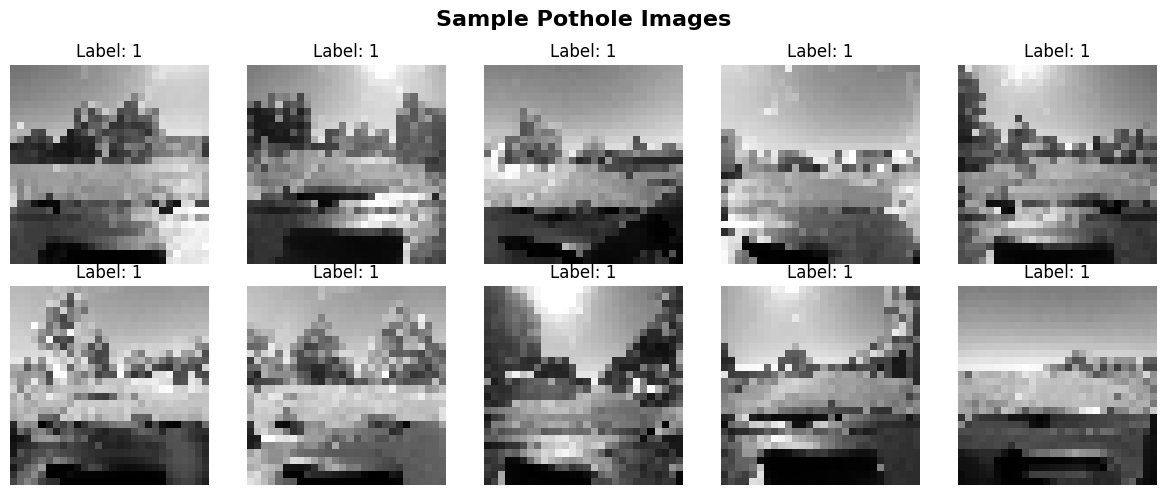

In [ ]:
visualize_samples(X_train, y_train)

In [ ]:
preprocess_image_data(X_train, y_train )

Starting Preprocessing...
  - Skip Normalization: Data already in range 0.0 to 1.0
  - Skip Reshape: Dimensions already (3744, 28, 28, 1)
  - Skip Encoding: Label shape already (3744, 2)


(array([[[[0.45882353],
          [0.45490196],
          [0.4627451 ],
          ...,
          [0.8627451 ],
          [0.8509804 ],
          [0.84313726]],
 
         [[0.47058824],
          [0.47058824],
          [0.48235294],
          ...,
          [0.8352941 ],
          [0.81960785],
          [0.8156863 ]],
 
         [[0.4862745 ],
          [0.49411765],
          [0.49411765],
          ...,
          [0.80784315],
          [0.8       ],
          [0.79607844]],
 
         ...,
 
         [[0.23921569],
          [0.26666668],
          [0.2627451 ],
          ...,
          [0.93333334],
          [0.92156863],
          [0.99607843]],
 
         [[0.26666668],
          [0.2509804 ],
          [0.2509804 ],
          ...,
          [0.9098039 ],
          [0.8901961 ],
          [0.89411765]],
 
         [[0.25490198],
          [0.25882354],
          [0.23921569],
          ...,
          [0.89411765],
          [0.8980392 ],
          [0.9372549 ]]],
 
 
        [

# Building Our CNN

In [ ]:
# 1. Build and Compile the model using your custom def
pothole_model = build_pothole_cnn()
pothole_model.summary()
# 2. Run the Training Loop
# We use 10 epochs and a batch size of 128 as seen in the walkthrough
# ==========================================
# EXECUTION
# ==========================================
# Just call this once after you've loaded your data and built your model
history = train_and_evaluate_pothole_model(pothole_model, X_train, y_train, X_test, y_test)

print("\n✅ Training complete!")

✅ Model built and compiled successfully!


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 224,002 (875.01 KB)

 Trainable params: 224,002 (875.01 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10


In [ ]:
test_loss, test_accuracy = pothole_model.evaluate(X_test, y_test, verbose=0)

print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Test Loss:     {test_loss:.4f}")
print(f"\nOur CNN correctly classifies {test_accuracy*100:.2f}% of handwritten digits it has never seen before!")